#KPI Dashboard Metrics

## Objective

The objective of this analysis is to calculate key business performance indicators (KPIs) that provide a high-level summary of Amazon sales performance.

These KPIs can be used by business leaders to monitor performance and make strategic decisions.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/cleaned_amazon_sales.csv')

df['Date'] = pd.to_datetime(df['Date'])

In [3]:
total_revenue = df['Amount'].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹78,478,115.39


In [4]:
total_orders = df['Order ID'].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 120,201


In [5]:
aov = df['Amount'].mean()

print(f"Average Order Value: ₹{aov:.2f}")

Average Order Value: ₹648.64


In [6]:
cancelled_orders = (
    df['Status']
    .str.contains(
        'Cancelled',
        case=False,
        na=False
    )
    .sum()
)

cancel_rate = (
    cancelled_orders /
    len(df)
) * 100

print(f"Cancellation Rate: {cancel_rate:.2f}%")

Cancellation Rate: 14.21%


In [7]:
top_category = (
    df.groupby('Category')['Amount']
    .sum()
    .idxmax()
)

print(top_category)

T-shirt


In [8]:
top_state = (
    df.groupby('ship-state')['Amount']
    .sum()
    .idxmax()
)

print(top_state)

MAHARASHTRA


In [9]:
b2b_revenue = (
    df[df['B2B'] == True]['Amount']
    .sum()
)

b2b_pct = (
    b2b_revenue /
    total_revenue
) * 100

print(f"{b2b_pct:.2f}%")

0.75%


In [10]:
success_rate = (
    100 - cancel_rate
)

print(f"{success_rate:.2f}%")

85.79%


In [11]:
kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Orders',
        'Average Order Value',
        'Cancellation Rate',
        'Successful Order Rate',
        'Top Category',
        'Top State',
        'B2B Revenue %'
    ],
    'Value': [
        total_revenue,
        total_orders,
        aov,
        cancel_rate,
        success_rate,
        top_category,
        top_state,
        b2b_pct
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,78478115.39
1,Total Orders,120201
2,Average Order Value,648.643794
3,Cancellation Rate,14.213939
4,Successful Order Rate,85.786061
5,Top Category,T-shirt
6,Top State,MAHARASHTRA
7,B2B Revenue %,0.753358


In [12]:
kpi_summary

,Metric,Value
0,Total Revenue,78478115.39
1,Total Orders,120201
2,Average Order Value,648.643794
3,Cancellation Rate,14.213939
4,Successful Order Rate,85.786061
5,Top Category,T-shirt
6,Top State,MAHARASHTRA
7,B2B Revenue %,0.753358


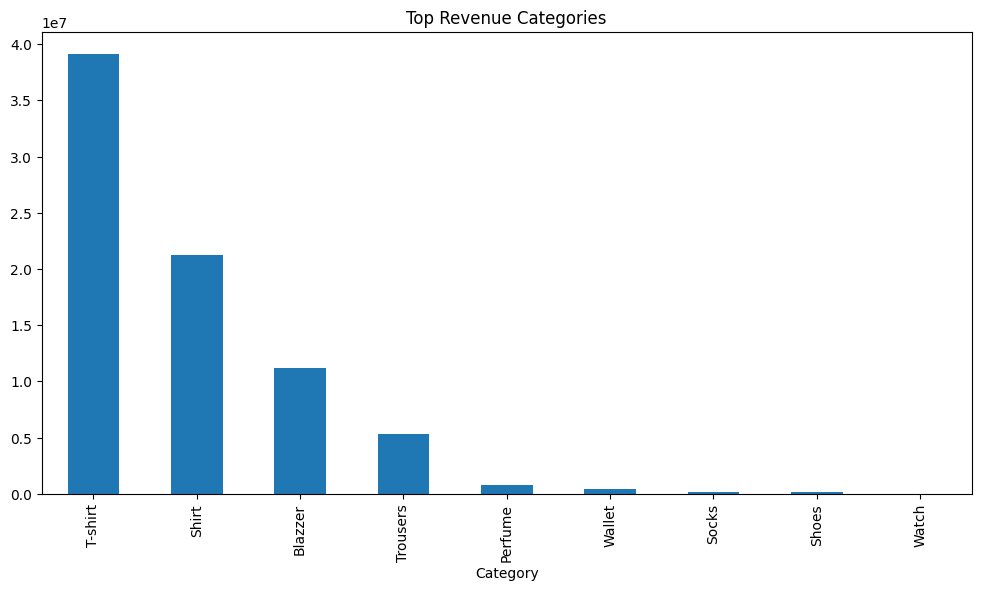

In [13]:
plt.figure(figsize=(12,6))

(
    df.groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
).plot(kind='bar')

plt.title('Top Revenue Categories')

plt.show()

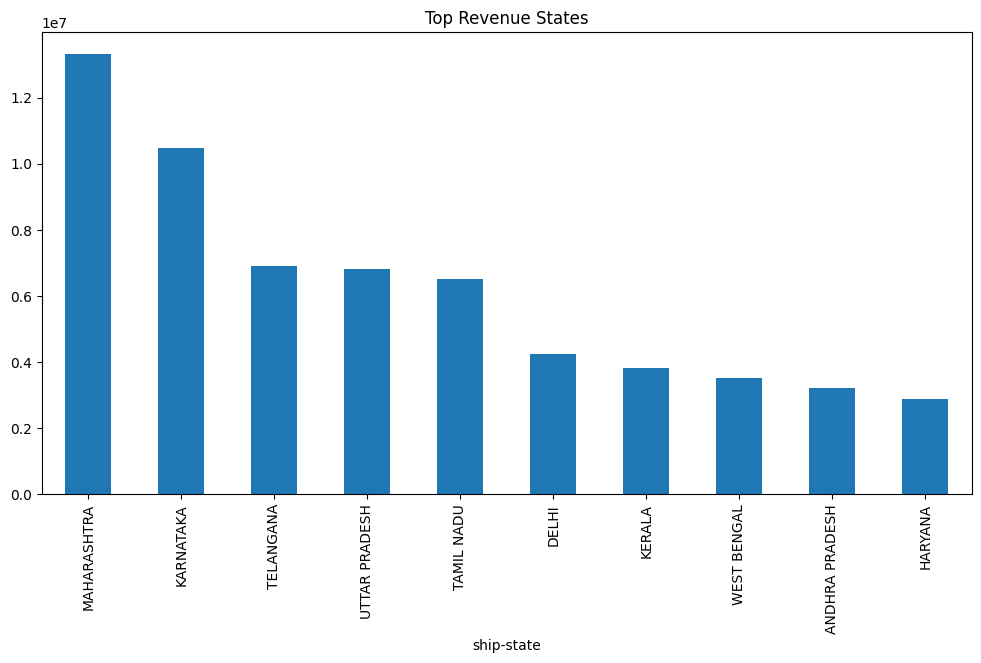

In [14]:
plt.figure(figsize=(12,6))

(
    df.groupby('ship-state')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
).plot(kind='bar')

plt.title('Top Revenue States')

plt.show()

# Executive Summary

## Business Performance Overview

- Total Revenue Generated: ₹ 78478115.39
- Total Orders Processed: 120201
- Average Order Value: ₹ 648.64
- Cancellation Rate: 14.21%
- Successful Order Rate: 85.78%

## Top Performers

- Highest Revenue Category: T-shirt
- Highest Revenue State: Maharashtra
- B2B Revenue Contribution: 0.75%

## Strategic Insight

The business demonstrates strong sales performance driven primarily by T-shirt category products and strong demand from Maharashtra. Operational performance remains healthy, though reducing cancellations could further improve revenue and customer satisfaction.

# Business Recommendations

1. Increase focus on the highest revenue-generating category.
2. Strengthen operations in top-performing states.
3. Reduce cancellation rates through better order management.
4. Expand marketing efforts toward high-value customer segments.
5. Use KPI monitoring for continuous performance tracking.